# Self-Supervised Image Representation Learning using Masked Autoencoders (MAE)

## Environment Setup and Dataset Loading

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import math
import os
import glob
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CANDIDATES = [
    "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200",
    "/kaggle/input/tiny-imagenet/tiny-imagenet-200",
    "/kaggle/input/tiny-imagenet",
]

DATA_ROOT = None
for c in CANDIDATES:
    if os.path.isdir(os.path.join(c, "train")):
        DATA_ROOT = c
        break

if DATA_ROOT is None:
    for root, dirs, files in os.walk("/kaggle/input"):
        if "train" in dirs and any(d.startswith("n0") for d in os.listdir(os.path.join(root, "train"))):
            DATA_ROOT = root
            break

if DATA_ROOT is None:
    raise RuntimeError("Cannot find dataset. /kaggle/input contents: " + str(os.listdir("/kaggle/input")))

print("DATA_ROOT:", DATA_ROOT)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=transform)

class FlatImageDataset(Dataset):
    def __init__(self, folder, transform=None):
        exts = (".jpg", ".jpeg", ".png", ".JPEG", ".PNG", ".JPG")
        self.paths = sorted([
            p for p in glob.glob(os.path.join(folder, "**", "*"), recursive=True)
            if os.path.isfile(p) and p.endswith(exts)
        ])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, 0

VAL_IMAGES_DIR = os.path.join(DATA_ROOT, "val", "images")
if os.path.isdir(VAL_IMAGES_DIR):
    val_dataset = FlatImageDataset(VAL_IMAGES_DIR, transform=transform)
else:
    val_dataset = FlatImageDataset(os.path.join(DATA_ROOT, "val"), transform=transform)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Device: cuda
DATA_ROOT: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
Train samples: 100000
Val samples: 10000


## Patchification and Masking Utilities

In [25]:
def patchify(imgs, patch_size=16):
    B, C, H, W = imgs.shape
    h = w = H // patch_size
    x = imgs.reshape(B, C, h, patch_size, w, patch_size)
    x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, h * w, patch_size * patch_size * C)
    return x

def unpatchify(patches, patch_size=16, img_size=224):
    B = patches.shape[0]
    h = w = img_size // patch_size
    C = 3
    x = patches.reshape(B, h, w, patch_size, patch_size, C)
    x = x.permute(0, 5, 1, 3, 2, 4).reshape(B, C, img_size, img_size)
    return x

def random_masking(x, mask_ratio=0.75):
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    noise = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    ids_keep = ids_shuffle[:, :len_keep]
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore, ids_keep

## Vision Transformer Encoder (ViT-Base B/16)

In [26]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        y = self.norm1(x)
        y, _ = self.attn(y, y, y)
        x = x + y
        x = x + self.mlp(self.norm2(x))
        return x


def get_sincos_pos_embed(num_patches, embed_dim):
    pos = torch.arange(num_patches).unsqueeze(1).float()
    dim = torch.arange(embed_dim).float()
    dim = 2 * (dim // 2) / embed_dim
    pos_embed = pos / (10000 ** dim)
    pos_embed[:, 0::2] = torch.sin(pos_embed[:, 0::2])
    pos_embed[:, 1::2] = torch.cos(pos_embed[:, 1::2])
    return pos_embed.unsqueeze(0)


class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed = nn.Linear(patch_size * patch_size * in_chans, embed_dim)
        self.pos_embed = nn.Parameter(get_sincos_pos_embed(self.num_patches, embed_dim), requires_grad=False)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x, ids_keep):
        x = self.patch_embed(x)
        pos = self.pos_embed.expand(x.shape[0], -1, -1)
        pos_vis = torch.gather(pos, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, pos.shape[2]))
        x = x + pos_vis
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x

## Vision Transformer Decoder (ViT-Small S/16)

In [27]:
class MAEDecoder(nn.Module):
    def __init__(self, num_patches=196, encoder_dim=768, decoder_dim=384, depth=12, num_heads=6, patch_size=16, in_chans=3):
        super().__init__()
        self.num_patches = num_patches
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.pos_embed = nn.Parameter(get_sincos_pos_embed(num_patches, decoder_dim), requires_grad=False)
        self.blocks = nn.ModuleList([TransformerBlock(decoder_dim, num_heads) for _ in range(depth)])
        self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, patch_size * patch_size * in_chans)

    def forward(self, x, ids_restore):
        x = self.decoder_embed(x)
        B, N_vis, D = x.shape
        mask_tokens = self.mask_token.expand(B, self.num_patches - N_vis, -1)
        x_full = torch.cat([x, mask_tokens], dim=1)
        x_full = torch.gather(x_full, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, D))
        x_full = x_full + self.pos_embed.expand(B, -1, -1)
        for blk in self.blocks:
            x_full = blk(x_full)
        x_full = self.norm(x_full)
        x_full = self.pred(x_full)
        return x_full

## Masked Autoencoder (MAE) Full Model

In [28]:
class MaskedAutoencoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3,
                 encoder_dim=768, encoder_depth=12, encoder_heads=12,
                 decoder_dim=384, decoder_depth=12, decoder_heads=6):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.encoder = MAEEncoder(img_size, patch_size, in_chans, encoder_dim, encoder_depth, encoder_heads)
        self.decoder = MAEDecoder(self.num_patches, encoder_dim, decoder_dim, decoder_depth, decoder_heads, patch_size, in_chans)

    def forward(self, imgs, mask_ratio=0.75):
        patches = patchify(imgs, self.patch_size)
        x_visible, mask, ids_restore, ids_keep = random_masking(patches, mask_ratio)
        latent = self.encoder(x_visible, ids_keep)
        pred = self.decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask

    def forward_loss(self, imgs, pred, mask):
        target = patchify(imgs, self.patch_size)
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss

model = MaskedAutoencoder().to(device)
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
total_params = sum(p.numel() for p in model.parameters())
print(f"Encoder: {encoder_params/1e6:.1f}M")
print(f"Decoder: {decoder_params/1e6:.1f}M")
print(f"Total: {total_params/1e6:.1f}M")

Encoder: 85.8M
Decoder: 22.0M
Total: 107.8M


## Dataset Preparation and DataLoaders

In [29]:
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True,
    persistent_workers=True, prefetch_factor=2
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True,
    persistent_workers=True, prefetch_factor=2
)

sample_batch, _ = next(iter(train_loader))
print("Batch shape:", sample_batch.shape)

Batch shape: torch.Size([64, 3, 224, 224])


## Training Loop with Mixed Precision

In [30]:
NUM_EPOCHS = 50
CKPT_PATH = "mae_model.pth"
RESUME = os.path.exists(CKPT_PATH)

model = nn.DataParallel(model)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.5e-4, betas=(0.9, 0.95), weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.amp.GradScaler("cuda")

train_losses = []
start_epoch = 0

if RESUME:
    ckpt = torch.load(CKPT_PATH, map_location=device)
    if isinstance(ckpt, dict) and "epoch" in ckpt:
        model.module.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        train_losses = ckpt["losses"]
        start_epoch = ckpt["epoch"]
        print(f"Resumed from epoch {start_epoch}")

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    count = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            loss, pred, mask = model(imgs, mask_ratio=0.75)
            loss = loss.mean()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()
        count += 1
    scheduler.step()
    avg_loss = epoch_loss / count
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} Loss: {avg_loss:.6f}")
    torch.save({
        "epoch": epoch + 1,
        "model": model.module.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "losses": train_losses,
    }, CKPT_PATH)

torch.save(model.module.state_dict(), "mae_model_final.pth")

Resumed from epoch 50


## Loss Curve

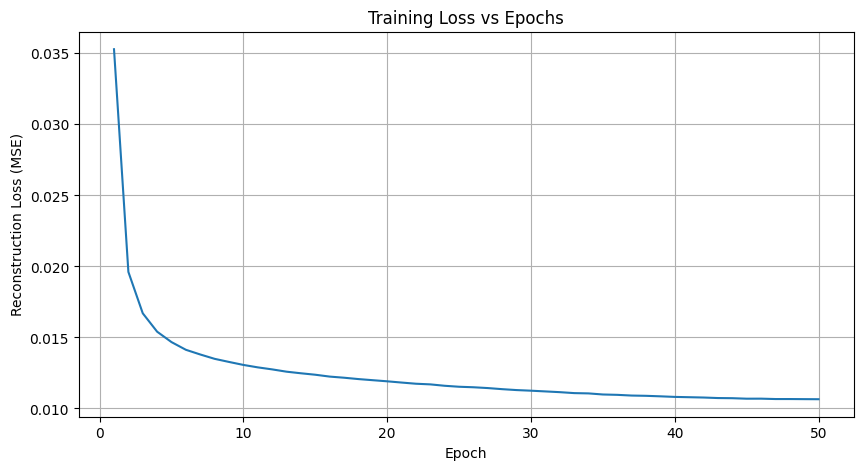

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Quantitative Evaluation (PSNR and SSIM)

In [32]:
eval_model = MaskedAutoencoder().to(device)
ckpt = torch.load("mae_model.pth", map_location=device)
state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
eval_model.load_state_dict(state_dict)
eval_model.eval()

val_imgs, _ = next(iter(val_loader))
val_imgs = val_imgs.to(device)

with torch.no_grad():
    loss, pred, mask = eval_model(val_imgs, mask_ratio=0.75)

pred_np = pred.cpu().numpy()
target_patches = patchify(val_imgs).cpu().numpy()
mask_np = mask.cpu().numpy()

psnr_scores = []
ssim_scores = []

for i in range(5):
    recon_patches = pred_np[i].copy()
    orig_patches = target_patches[i].copy()
    m = mask_np[i]
    combined = orig_patches.copy()
    combined[m == 1] = recon_patches[m == 1]
    recon_img = unpatchify(torch.tensor(combined).unsqueeze(0)).squeeze(0).permute(1, 2, 0).numpy()
    orig_img = val_imgs[i].cpu().permute(1, 2, 0).numpy()
    recon_img = np.clip(recon_img, 0, 1)
    orig_img = np.clip(orig_img, 0, 1)
    p = peak_signal_noise_ratio(orig_img, recon_img, data_range=1.0)
    s = structural_similarity(orig_img, recon_img, data_range=1.0, channel_axis=2)
    psnr_scores.append(p)
    ssim_scores.append(s)
    print(f"Sample {i+1} - PSNR: {p:.2f} dB, SSIM: {s:.4f}")

print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
print(f"Average SSIM: {np.mean(ssim_scores):.4f}")

Sample 1 - PSNR: 17.50 dB, SSIM: 0.5848
Sample 2 - PSNR: 24.49 dB, SSIM: 0.7517
Sample 3 - PSNR: 26.25 dB, SSIM: 0.8709
Sample 4 - PSNR: 21.02 dB, SSIM: 0.6989
Sample 5 - PSNR: 27.39 dB, SSIM: 0.9057
Average PSNR: 23.33 dB
Average SSIM: 0.7624


## Visualization of Reconstructions

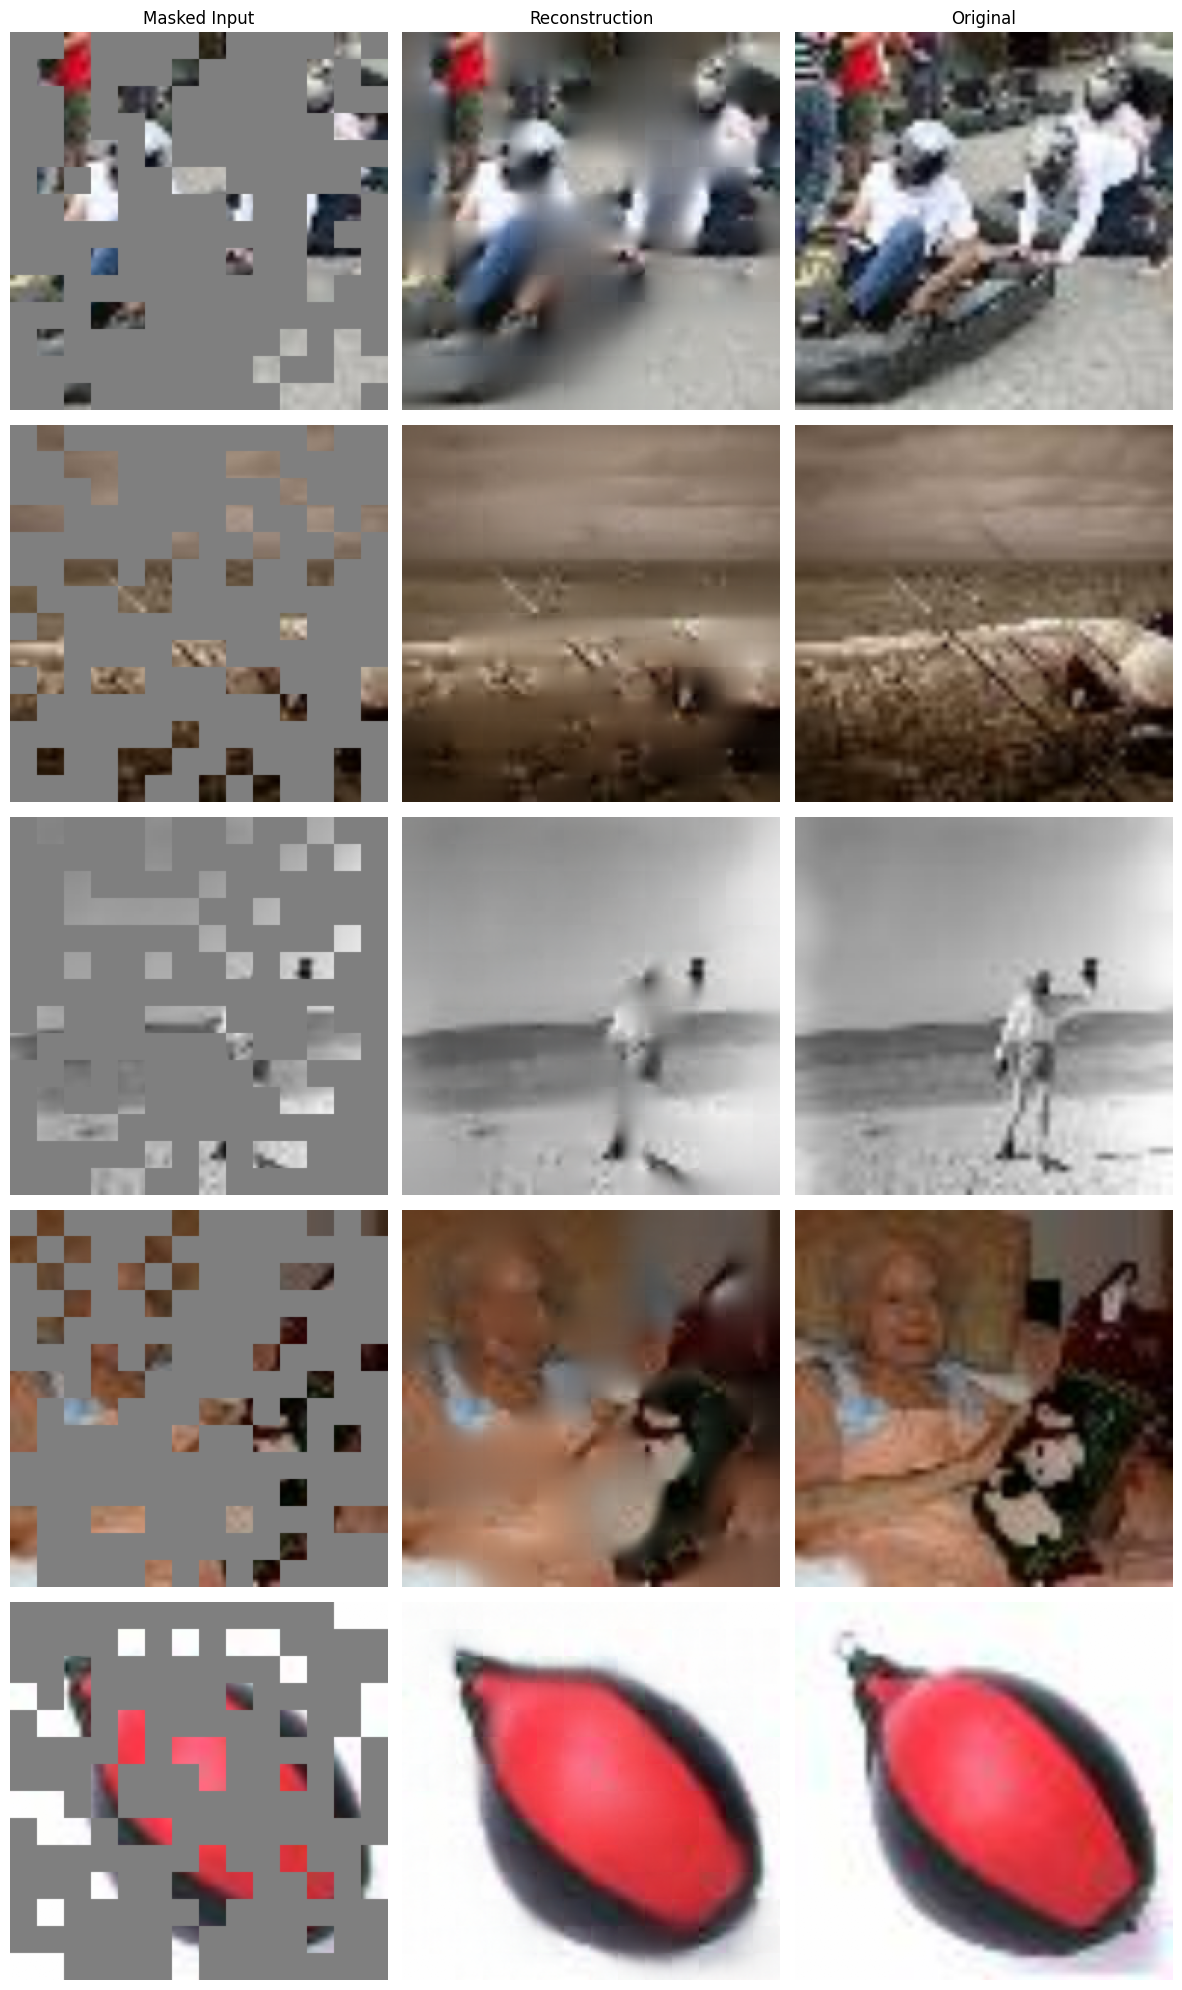

In [33]:
fig, axes = plt.subplots(5, 3, figsize=(12, 20))
columns = ["Masked Input", "Reconstruction", "Original"]
for col_idx, col_name in enumerate(columns):
    axes[0, col_idx].set_title(col_name)

for i in range(5):
    orig_img = val_imgs[i].cpu().permute(1, 2, 0).numpy()
    orig_img = np.clip(orig_img, 0, 1)

    orig_patches_i = target_patches[i].copy()
    m = mask_np[i]
    masked_patches = orig_patches_i.copy()
    masked_patches[m == 1] = 0.5
    masked_img = unpatchify(torch.tensor(masked_patches).unsqueeze(0)).squeeze(0).permute(1, 2, 0).numpy()
    masked_img = np.clip(masked_img, 0, 1)

    combined = orig_patches_i.copy()
    combined[m == 1] = pred_np[i][m == 1]
    recon_img = unpatchify(torch.tensor(combined).unsqueeze(0)).squeeze(0).permute(1, 2, 0).numpy()
    recon_img = np.clip(recon_img, 0, 1)

    axes[i, 0].imshow(masked_img)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(recon_img)
    axes[i, 1].axis("off")
    axes[i, 2].imshow(orig_img)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("reconstruction_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## Export Model and Hugging Face Deployment Files

In [34]:
ckpt = torch.load("mae_model.pth", map_location="cpu")
state_dict = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
torch.save(state_dict, "mae_model_final.pth")
print("Clean state dict saved as mae_model_final.pth")

Clean state dict saved as mae_model_final.pth
